# Logistic Regression

In this notebook, we will implement logistic regression algorithm. 
Logistic regression is a supervised learning algorithm used for classification problems, especially binary classification. Instead of predicting continuous values, it estimates the probability that an input belongs to a particular class using the sigmoid function. Despite its name, it is a classification method commonly used in applications like spam detection, medical diagnosis, and fraud detection.

In [1]:
import os
import numpy as np
from matplotlib import pyplot
from scipy import optimize
import utils

# tells matplotlib to embed plots within the notebook
%matplotlib inline

## Logistic Regression

The logistic regression model will be used here to predict whether a student gets admitted into a university. Suppose that you are the administrator of a university department and you want to determine each applicant’s chance of admission based on their results on two exams. You have historical data from previous applicants that you can use as a training set for logistic regression. For each training example, you have the applicant’s scores on two exams and the admissions decision. 
The classification model will estimate an applicant’s probability of admission based the scores from those two exams. 

In [2]:
# The first two columns contains the exam scores and the third column contains the label.
data = np.loadtxt(os.path.join('Data', 'exam_scores.csv'), delimiter=',')
X, y = data[:, 0:2], data[:, 2]

### Visualizing the data

We  display the data on a 2-dimensional plot by calling the function `plot_data`. 

In [3]:
def plot_data(X, y):
    """
    Plots the data points X and y into a new figure.
    
    Parameters
    ----------
    X : array_like
        An Mx2 matrix representing the dataset. 
    
    y : array_like
        Label values for the dataset. A vector of size (M, ).
    
    """
    # Create New Figure
    fig = pyplot.figure()

    pos = y == 1
    neg = y == 0
    
    pyplot.plot(X[pos, 0], X[pos, 1], 'ko', label='Positive examples', 
                markersize=8, linewidth=2,  markerfacecolor='green', markeredgecolor='k')
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', label='Negative examples', 
                markersize=8, linewidth=2, markerfacecolor='red', markeredgecolor='k')  


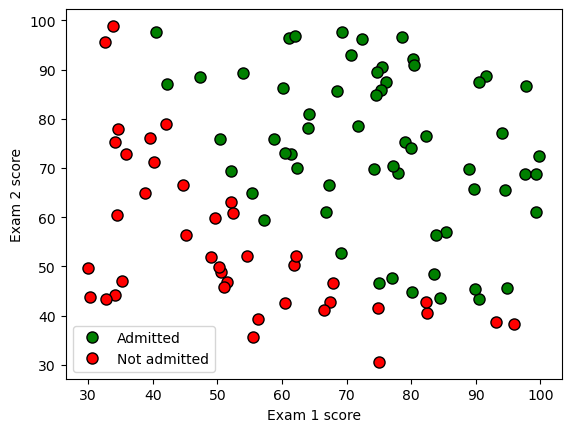

In [4]:
plot_data(X, y)
# add axes labels
pyplot.xlabel('Exam 1 score')
pyplot.ylabel('Exam 2 score')
pyplot.legend(['Admitted', 'Not admitted'])
pass

### Sigmoid function

The logistic regression hypothesis is defined as:

$$ h_\theta(x) = g(\theta^T x)$$

where function $g$ is the sigmoid function. The sigmoid function is defined as: 

$$g(z) = \frac{1}{1+e^{-z}}$$

For large positive values of `x`, the sigmoid should be close to 1, while for large negative values, the sigmoid should be close to 0. Evaluating `sigmoid(0)` should give you exactly 0.5.

In [5]:
def sigmoid(z):
    """
    Compute sigmoid function given the input z.
    
    Parameters
    ----------
    z : array_like (it can be a matrix, vector or scalar)
        The input to the sigmoid function. This can be a 1-D vector 
        or a 2-D matrix. 
    
    Returns
    -------
    g : array_like
        The computed sigmoid function. g has the same shape as z, since
        the sigmoid is computed element-wise on z.        
    """
    
    # convert input to a numpy array
    z = np.array(z)
    
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))

    return g

In [6]:
# Testing sigmoid function implementation
# For z = 0, the value should be 0.5
z = 0
g = sigmoid(z)
print('g(', z, ') = ', g)

z = -50
g = sigmoid(z)
print('g(', z, ') = ', g)

z = -5
g = sigmoid(z)
print('g(', z, ') = ', g)

z = 45
g = sigmoid(z)
print('g(', z, ') = ', g)

z = 3
g = sigmoid(z)
print('g(', z, ') = ', g)

g( 0 ) =  0.5
g( -50 ) =  1.928749847963918e-22
g( -5 ) =  0.0066928509242848554
g( 45 ) =  1.0
g( 3 ) =  0.9525741268224334


#### Cost function and gradient

In [7]:
# Setup the data matrix appropriately, and add ones for the intercept term
m, n = X.shape

# Add intercept term to X
X = np.concatenate([np.ones((m, 1)), X], axis=1)

The cost function in logistic regression is

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

and the gradient of the cost is a vector of the same length as $\theta$ where the $j^{th}$
element (for $j = 0, 1, \cdots , n$) is defined as follows:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Note that while this gradient looks identical to the linear regression gradient, the formula is actually different because linear and logistic regression have different definitions of $h_\theta(x)$.


In [8]:
def cost_function(theta, X, y):
    """
    Compute cost and gradient for logistic regression. 
    
    Parameters
    ----------
    theta : array_like
        The parameters for logistic regression. This a vector
        of shape (n+1, ).
    
    X : array_like
        The input dataset of shape (m x n+1) where m is the total number
        of data points and n is the number of features. We assume the 
        intercept has already been added to the input.
    
    y : array_like
        Labels for the input. This is a vector of shape (m, ).
    
    Returns
    -------
    J : float
        The computed value for the cost function. 
    
    grad : array_like
        A vector of shape (n+1, ) which is the gradient of the cost
        function with respect to theta, at the current values of theta.        
    """

    assert X.shape[0] == y.shape[0]
    assert X.shape[1] == theta.shape[0]
    
    # number of training examples
    m = y.size

    grad = np.zeros(theta.shape)    


    h = sigmoid(X @ theta)

    # Add an epsilon to avoid log(0)
    epsilon = 1e-15 # A very small positive number
    h = np.clip(h, epsilon, 1 - epsilon)

    J = (1/m) * np.sum(- y * np.log(h) - (1 - y) * np.log(1 - h))

    grad = (1/m) * (h - y).dot(X)
    
    return J, grad

In [9]:
# Initialize fitting parameters
initial_theta = np.zeros(n+1)

cost, grad = cost_function(initial_theta, X, y)

print('Cost at initial theta (zeros): {:.3f}'.format(cost))

print('Gradient at initial theta (zeros):')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad))

# Compute and display cost and gradient with non-zero theta
test_theta = np.array([-24, 0.2, 0.2])
cost, grad = cost_function(test_theta, X, y)

print('Cost at test theta: {:.3f}'.format(cost))

print('Gradient at test theta:')
print('\t[{:.3f}, {:.3f}, {:.3f}]'.format(*grad))

Cost at initial theta (zeros): 0.693
Gradient at initial theta (zeros):
	[-0.1000, -12.0092, -11.2628]
Cost at test theta: 0.218
Gradient at test theta:
	[0.043, 2.566, 2.647]


#### Learning parameters using `scipy.optimize`

For logistic regression, you want to optimize the cost function $J(\theta)$ with parameters $\theta$.
Next, we are going to use `optimize.minimize` to find the best parameters $\theta$ for the logistic regression cost function, given a fixed dataset (of X and y values). 

Using `cost_function` implemented before, `optimize.minimize` will converge on the right optimization parameters and return the final values of the cost and $\theta$ in a class object. Notice that by using `optimize.minimize`, we did not have to write any loops, or set a learning rate like we did for gradient descent. This is all done by `optimize.minimize`: we only needed to provide a function calculating the cost and the gradient.


In [10]:
options= {'maxfun': 400}

"""
cost_function: A cost function that, when given the training set and a particular theta, computes the logistic regression cost and 
               gradient with respect to theta for the dataset (X, y). 
initial_theta: The initial values of the parameters we are trying to optimize.
(X, y): These are additional arguments to the cost function.
jac: Indication if the cost function returns the Jacobian (gradient) along with cost value. (True)
method: Optimization method/algorithm to use
options: Additional options which might be specific to tje optimization method. In the following, we only 
         tell the algorithm the maximum number of iterations before it terminates.
"""

res = optimize.minimize(cost_function,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

# the fun property of `OptimizeResult` object returns
# the value of cost_function at optimized theta
cost = res.fun

# the optimized theta is in the x property
theta = res.x

# Print theta to screen
print('Cost at theta found by optimize.minimize: {:.3f}'.format(cost))
print('Expected cost (approx): 0.203\n');

print('theta:')
print('\t[{:.3f}, {:.3f}, {:.3f}]'.format(*theta))
print('Expected theta (approx):\n\t[-25.161, 0.206, 0.201]')

Cost at theta found by optimize.minimize: 0.203
Expected cost (approx): 0.203

theta:
	[-25.161, 0.206, 0.201]
Expected theta (approx):
	[-25.161, 0.206, 0.201]


Once `optimize.minimize` completes, we want to use the final value for $\theta$ to visualize the decision boundary.

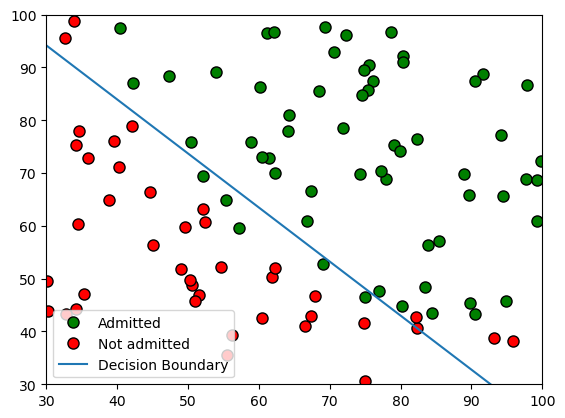

In [11]:
# Plot Boundary
utils.plot_decision_boundary(plot_data, theta, X, y)

#### Evaluating logistic regression

After learning the parameters, we can use the model to predict whether a particular student will be admitted. 
The predict function will produce “1” or “0” predictions given a dataset and a learned parameter vector $\theta$. 

In [12]:
def predict(theta, X):
    """
    Predict whether the label is 0 or 1 using learned logistic regression.
    Computes the predictions for X using a threshold at 0.5 
    (i.e., if sigmoid(theta.T*x) >= 0.5, predict 1)
    
    Parameters
    ----------
    theta : array_like
        Parameters for logistic regression. A vector of shape (n+1, ).
    
    X : array_like
        The data to use for computing predictions. The rows is the number 
        of points to compute predictions, and columns is the number of
        features.

    Returns
    -------
    p : array_like
        Predictions and 0 or 1 for each row in X. 

    """
    m = X.shape[0] 
    p = np.zeros(m)

    res =  sigmoid(X.dot(theta))
    for i in range(0, m):
        if res[i] >= 0.5:
            p[i] = 1 
    return p

Let's report the training accuracy of our classifier by computing the percentage of examples it got correct.

In [13]:
#  Predict probability for a student with score 45 on exam 1 
#  and score 85 on exam 2 
prob = sigmoid(np.dot([1, 45, 85], theta))
print('For a student with scores 45 and 85,'
      'we predict an admission probability of {:.3f}'.format(prob))

# Compute accuracy on our training set
p = predict(theta, X)
print('Train Accuracy: {:.2f} %'.format(np.mean(p == y) * 100))

For a student with scores 45 and 85,we predict an admission probability of 0.776
Train Accuracy: 89.00 %


## Regularized logistic regression

Now, we are going to implement regularized logistic regression to predict whether microchips from a fabrication plant passes quality assurance (QA). During QA, each microchip goes through various tests to ensure it is functioning correctly.
Suppose you are the product manager of the factory and you have the test results for some microchips on two different tests. From these two tests, you would like to determine whether the microchips should be accepted or rejected. To help you make the decision, you have a dataset of test results on past microchips, from which you can build a logistic regression model.


In [14]:
# Load Data
# The first two columns contains the X values and the third column contains the label (y).
data = np.loadtxt(os.path.join('Data', 'microchips_data.csv'), delimiter=',')
X = data[:, :2]
y = data[:, 2]

### Visualize the data

The function`plot_data` is used to generate a figure, where the axes are the two test scores, and the positive (y = 1, accepted) and negative (y = 0, rejected) examples are shown with different markers.

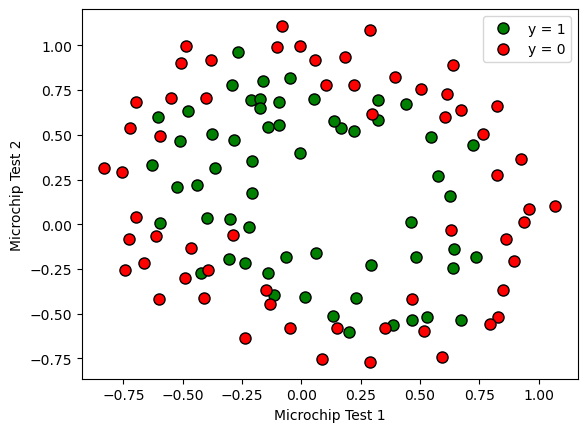

In [15]:
plot_data(X, y)
# Labels and Legend
pyplot.xlabel('Microchip Test 1')
pyplot.ylabel('Microchip Test 2')

# Specified in plot order
pyplot.legend(['y = 1', 'y = 0'], loc='upper right')
pass

The above figure shows that our dataset cannot be separated into positive and negative examples by a straight-line through the plot. Therefore, a straight-forward application of logistic regression will not perform well on this dataset since logistic regression will only be able to find a linear decision boundary.

### Feature mapping

One way to fit the data better is to create more features from each data point. In the function `map_feature` defined in the file `utils.py`, we will map the features into all polynomial terms of $x_1$ and $x_2$ up to the sixth power.

$$ \text{mapFeature}(x) = \begin{bmatrix} 1 & x_1 & x_2 & x_1^2 & x_1 x_2 & x_2^2 & x_1^3 & \dots & x_1 x_2^5 & x_2^6 \end{bmatrix}^T $$

As a result of this mapping, our vector of two features (the scores on two QA tests) has been transformed into a 28-dimensional vector. A logistic regression classifier trained on this higher-dimension feature vector will have a more complex decision boundary and will appear nonlinear when drawn in our 2-dimensional plot.
While the feature mapping allows us to build a more expressive classifier, it also more susceptible to overfitting. The regularized logistic regression implementation can help combat the overfitting problem.


In [16]:
# Note that map_feature also adds a column of ones for us, so the intercept term is handled
X = utils.map_feature(X[:, 0], X[:, 1])

### Cost function and gradient

Recall that the regularized cost function in logistic regression is

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)}\log \left( h_\theta \left(x^{(i)} \right) \right) - \left( 1 - y^{(i)} \right) \log \left( 1 - h_\theta \left( x^{(i)} \right) \right) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2 $$

Note that you should not regularize the parameters $\theta_0$. The gradient of the cost function is a vector where the $j^{th}$ element is defined as follows:

$$ \frac{\partial J(\theta)}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left(x^{(i)}\right) - y^{(i)} \right) x_j^{(i)} \qquad \text{for } j =0 $$

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \left( \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left(x^{(i)}\right) - y^{(i)} \right) x_j^{(i)} \right) + \frac{\lambda}{m}\theta_j \qquad \text{for } j \ge 1 $$


In [17]:
def cost_function_reg(theta, X, y, lambda_):
    """
    Compute cost and gradient for logistic regression with regularization.
    
    Parameters
    ----------
    theta : array_like
        Logistic regression parameters. A vector with shape (n, ). n is 
        the number of features including any intercept. If we have mapped
        our initial features into polynomial features, then n is the total 
        number of polynomial features. 
    
    X : array_like
        The data set with shape (m x n). m is the number of examples, and
        n is the number of features (after feature mapping).
    
    y : array_like
        The data labels. A vector with shape (m, ).
    
    lambda_ : float
        The regularization parameter. 
    
    Returns
    -------
    J : float
        The computed value for the regularized cost function. 
    
    grad : array_like
        A vector of shape (n, ) which is the gradient of the cost
        function with respect to theta, at the current values of theta.
    
    """
    
    m = y.size  # number of training examples

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta))

    theta_modified = np.copy(theta)
    theta_modified[0] = 0

    first_term = -y.dot(np.log(h))  
    second_term = (1-y).dot(np.log(1 - h))
    regularization_param = lambda_/(2*m) * np.sum(np.power(theta_modified, 2))

    J = (1/m) * np.sum(first_term - second_term) + regularization_param
    
    grad = (1/m) * (h - y).dot(X) + (lambda_/m * theta_modified)
    
    return J, grad

In [18]:
initial_theta = np.zeros(X.shape[1])

# Set regularization parameter lambda to 1
lambda_ = 1

# Compute and display initial cost and gradient for regularized logistic regression
cost, grad = cost_function_reg(initial_theta, X, y, lambda_)

print('Cost at initial theta (zeros): {:.3f}'.format(cost))

print('Gradient at initial theta (zeros) - first five values only:')
print('\t[{:.4f}, {:.4f}, {:.4f}, {:.4f}, {:.4f}]'.format(*grad[:5]))

# Compute and display cost and gradient
# with all-ones theta and lambda = 10
test_theta = np.ones(X.shape[1])
cost, grad = cost_function_reg(test_theta, X, y, 10)

print('------------------------------\n')
print('Cost at test theta    : {:.2f}'.format(cost))

print('Gradient at test theta - first five values only:')
print('\t[{:.4f}, {:.4f}, {:.4f}, {:.4f}, {:.4f}]'.format(*grad[:5]))

Cost at initial theta (zeros): 0.693
Gradient at initial theta (zeros) - first five values only:
	[0.0085, 0.0188, 0.0001, 0.0503, 0.0115]
------------------------------

Cost at test theta    : 3.16
Gradient at test theta - first five values only:
	[0.3460, 0.1614, 0.1948, 0.2269, 0.0922]


### Decision boundaries

Here, we will try out different regularization parameters for the dataset to understand how regularization prevents overfitting.

Notice the changes in the decision boundary as you vary $\lambda$. With a small
$\lambda$, you should find that the classifier gets almost every training example correct, but draws a very complicated boundary, thus overfitting the data. 

With a larger $\lambda$, you should see a plot that shows a simpler decision boundary which still separates the positives and negatives fairly well. However, if $\lambda$ is set to too high a value, you will not get a good fit and the decision boundary will not follow the data so well, thus underfitting the data.

Train Accuracy: 83.1 %


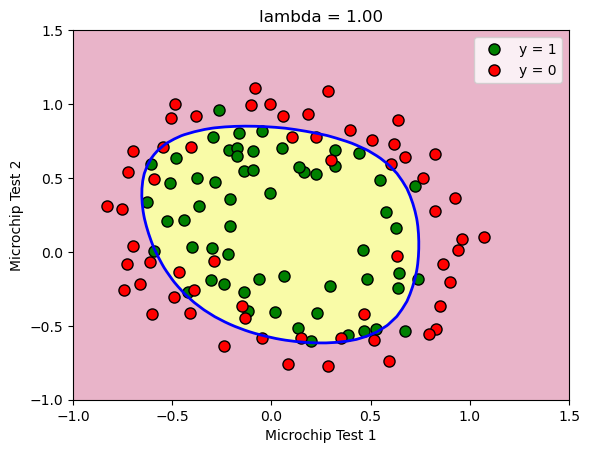

In [19]:
# Initialize fitting parameters
initial_theta = np.zeros(X.shape[1])

# Set regularization parameter lambda to 1 (we will vary this)
lambda_ = 1

# set options for optimize.minimize
options= {'maxfun': 100}


res = optimize.minimize(cost_function_reg,
                        initial_theta,
                        (X, y, lambda_),
                        jac=True,
                        method='TNC',
                        options=options)

# the fun property of OptimizeResult object returns
# the value of cost_function at optimized theta
cost = res.fun

# the optimized theta is in the x property of the result
theta = res.x

utils.plot_decision_boundary(plot_data, theta, X, y)
pyplot.xlabel('Microchip Test 1')
pyplot.ylabel('Microchip Test 2')
pyplot.legend(['y = 1', 'y = 0'])
pyplot.grid(False)
pyplot.title('lambda = %0.2f' % lambda_)

# Compute accuracy on our training set
p = predict(theta, X)

print('Train Accuracy: %.1f %%' % (np.mean(p == y) * 100))

Train Accuracy: 86.4 %


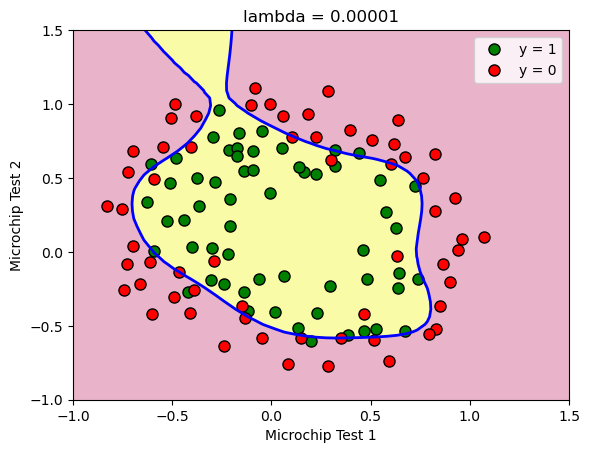

In [20]:
# Initialize fitting parameters
initial_theta = np.zeros(X.shape[1])

lambda_ = 0.00001

options= {'maxfun': 100}

res = optimize.minimize(cost_function_reg,
                        initial_theta,
                        (X, y, lambda_),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta = res.x

utils.plot_decision_boundary(plot_data, theta, X, y)
pyplot.xlabel('Microchip Test 1')
pyplot.ylabel('Microchip Test 2')
pyplot.legend(['y = 1', 'y = 0'])
pyplot.grid(False)
pyplot.title('lambda = %0.5f' % lambda_)

# Compute accuracy on our training set
p = predict(theta, X)

print('Train Accuracy: %.1f %%' % (np.mean(p == y) * 100))

Train Accuracy: 61.0 %


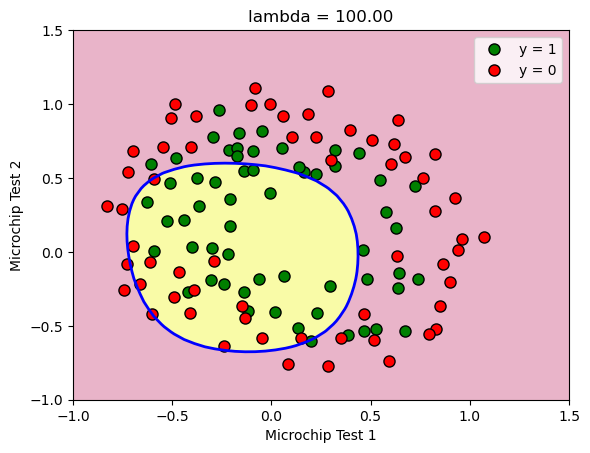

In [21]:
# Initialize fitting parameters
initial_theta = np.zeros(X.shape[1])

lambda_ = 100

options= {'maxfun': 100}

res = optimize.minimize(cost_function_reg,
                        initial_theta,
                        (X, y, lambda_),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta = res.x

utils.plot_decision_boundary(plot_data, theta, X, y)
pyplot.xlabel('Microchip Test 1')
pyplot.ylabel('Microchip Test 2')
pyplot.legend(['y = 1', 'y = 0'])
pyplot.grid(False)
pyplot.title('lambda = %0.2f' % lambda_)

# Compute accuracy on our training set
p = predict(theta, X)

print('Train Accuracy: %.1f %%' % (np.mean(p == y) * 100))